**MODELO DE APRENDIZAJE SUPERVISADO PARA LA CLASIFICACION DE FRUTAS**

El conjunto de datos utilizado en este proyecto corresponde a un registro estructurado de observaciones individuales de frutas, diseñado para representar de manera simplificada pero significativa las características físicas, sensoriales y económicas que comúnmente se emplean en la clasificación y evaluación de materias primas en la industria de alimentos. El dataset está conformado por **10,000 registros**, cada uno de los cuales describe una fruta mediante un conjunto de variables heterogéneas que incluyen **atributos cuantitativos y cualitativos, así como una etiqueta de clase que identifica el tipo de fruta.**

**OBJETIVO:**

Desarrollar y evaluar un modelo de aprendizaje automático supervisado capaz de clasificar correctamente distintos tipos de frutas a partir de sus características físicas, sensoriales y económicas, utilizando técnicas de Machine Learning aplicadas desde una perspectiva de Ciencia de Datos con fundamento en la Química de Alimentos.

**MODELOS**
Random Forest
DT
SVM

CONTENIDO:
1. BIBLIOTECAS Y CARGA DE DATA SET
2. EXPLORACION DE DATOS
3. LIMPIEZA
4. ESTADISTICAS DESCRIPTIVAS
5. PREPROCESAMIENTO DE DATOS
6. SPLIT DE DATOS
7. ENTRENAMIENTO DE MODELO
8. EVALUACION
9. DESPLIEGUE

Nota: Este cuaderno se desarrolló originalmente en Google Colab como parte de un trabajo de maestría.
Para fines de portafolio y reproducibilidad, el conjunto de datos se carga aquí utilizando una ruta de repositorio relativa.

In [ ]:
# ===============================
# 1. BIBLIOTECAS Y CONFIGURACIÓN
# ===============================

# Reproducibilidad
RANDOM_STATE = 42

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Machine Learning (clasificación)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Control de warnings (más seguro que "ignore" total)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("Bibliotecas cargadas correctamente. Entorno listo para clasificación multiclase.")

Bibliotecas cargadas correctamente. Entorno listo para clasificación multiclase.


In [ ]:
# ===============================
# 2. CARGA DEL DATASET
# ===============================

from pathlib import Path
from IPython.display import display
import pandas as pd

# Ruta relativa al repositorio
file_path = Path("../data/fruit_classification_dataset.csv")

# Validación de existencia
if not file_path.exists():
    raise FileNotFoundError(f"❌ No se encontró el archivo. Verifica la ruta:\n{file_path}")

# Lectura del dataset
try:
    df = pd.read_csv(file_path, encoding="utf-8", skipinitialspace=True)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin-1", skipinitialspace=True)

# Normalización de nombres de columnas
df.columns = df.columns.str.strip()

print("✅ Dataset loaded successfully.\n")

# Primeras filas
print("Primeras 5 filas del dataset:")
display(df.head())

# Dimensiones del dataset
print(f"\nShape del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

# Información general
print("\nInformación del dataset:")
df.info()

# Checks rápidos
print("\nNulos por columna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicados:", df.duplicated().sum())

expected_cols = {"fruit_name", "size (cm)", "weight (g)", "avg_price (₹)", "shape", "color", "taste"}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"❌ Faltan columnas esperadas: {missing}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded successfully.

Primeras 5 filas del dataset:


,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana



Shape del dataset: 10000 filas × 7 columnas

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB

Nulos por columna:


,0
size (cm),0
shape,0
weight (g),0
avg_price (₹),0
color,0
taste,0
fruit_name,0



Duplicados: 246


In [ ]:
print(f"INFO : Data describe \n{df.describe()}")

INFO : Data describe 
          size (cm)    weight (g)  avg_price (₹)
count  10000.000000  10000.000000   10000.000000
mean       8.430600    455.457720      77.016720
std        6.396915    731.643087      38.946916
min        0.900000      4.500000       9.000000
25%        3.700000     45.800000      45.575000
50%        7.200000    168.800000      75.400000
75%       10.100000    365.275000     100.700000
max       27.500000   3299.800000     165.000000


**LIMPIEZA DE DATOS**

In [ ]:
#LIMPIEZA DE DATOS

In [ ]:
print(f"INFO : Data columns \n{df.columns}")

INFO : Data columns 
Index(['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste',
       'fruit_name'],
      dtype='object')


In [ ]:
#Eliminar los datos duplicados (246) en este caso debido a que no se detectaron valores nulos no se aplica dropna sobre nulos
df.drop_duplicates(inplace= True)
print(f"INFO : Duplicate Values are dropped using 'drop_duplicates'")

INFO : Duplicate Values are dropped using 'drop_duplicates'


In [ ]:
#Corroborar que ya no tenemos datos duplicados
print(f"INFO : Data duplicated values \n{df.duplicated().sum()}")

#Comparativa
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"INFO: Duplicates removed: {before - after} | Rows before: {before} | Rows after: {after}")


INFO : Data duplicated values 
0
INFO: Duplicates removed: 0 | Rows before: 9754 | Rows after: 9754


In [ ]:
#Volvemos a calcular Estadisticas descriptivas pero ahora del dataset limpio
print(f"INFO : Estadísticas Descriptivas del Dataset Limpio ")
display(df.describe())

INFO : Estadísticas Descriptivas del Dataset Limpio 


,size (cm),weight (g),avg_price (₹)
count,9754.000000,9754.000000,9754.000000
mean,8.611195,466.779209,78.423621
std,6.372831,737.286782,38.324394
min,0.900000,4.500000,9.000000
25%,4.000000,47.600000,49.000000
50%,7.300000,177.200000,76.300000
75%,10.200000,375.650000,101.700000
max,27.500000,3299.800000,165.000000


In [ ]:
#DETECCIÓN DE OUTLIERS

def detect_and_remove_outliers_iqr(df, column):
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Print summary
    print(f"\n Column: {column}")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

    # Detect outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"\n Outliers Detected ({len(outliers)} rows):\n", outliers)

    # Remove outliers
    cleaned_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"\n Cleaned Data Size: {len(cleaned_df)} (from {len(df)})")

    return cleaned_df

# Get numerical columns for outlier detection
numerical_columns = df.select_dtypes(include='number').columns.to_list()

print("Numerical columns for outlier detection:", numerical_columns)

# Apply outlier detection and removal to each numerical column
for col in numerical_columns:
    df = detect_and_remove_outliers_iqr(df, col)

print(f"\nShape of DataFrame after outlier removal: {df.shape[0]} filas × {df.shape[1]} columnas")

Numerical columns for outlier detection: ['size (cm)', 'weight (g)', 'avg_price (₹)']

 Column: size (cm)
Q1: 4.00, Q3: 10.20, IQR: 6.20
Lower Bound: -5.30, Upper Bound: 19.50

 Outliers Detected (866 rows):
       size (cm)  shape  weight (g)  avg_price (₹)   color  taste  fruit_name
0          25.4  round      3089.2          137.1   green  sweet  watermelon
1          24.6  round      3283.9          163.8   green  sweet  watermelon
3          20.0   oval      1607.0           85.7  orange  sweet      papaya
43         27.2  round      2818.8          148.4   green  sweet  watermelon
50         24.8  round      3274.4          148.3   green  sweet  watermelon
...         ...    ...         ...            ...     ...    ...         ...
9938       21.0   oval      1610.0           73.3  orange  sweet      papaya
9952       26.3  round      3190.8          136.4   green  sweet  watermelon
9983       22.5  round      3202.0          156.5   green  sweet  watermelon
9988       21.5   ova

### Exploración de Variables Categóricas (Post-Limpieza)

Explorando variables categóricas:

--- Columna: shape ---
shape
round    3796
oval     3414
long      502
Name: count, dtype: int64


--- Columna: color ---
color
red       1920
green     1531
yellow    1002
pink       991
purple     835
brown      506
orange     484
blue       443
Name: count, dtype: int64


--- Columna: taste ---
taste
sweet    5752
tangy    1479
sour      481
Name: count, dtype: int64


--- Columna: fruit_name ---
fruit_name
pomegranate      534
pear             534
custard apple    516
kiwi             506
banana           502
mango            500
dragon fruit     496
lychee           495
apple            492
plum             489
orange           484
guava            481
cherry           462
blueberry        443
strawberry       432
grape            346
Name: count, dtype: int64




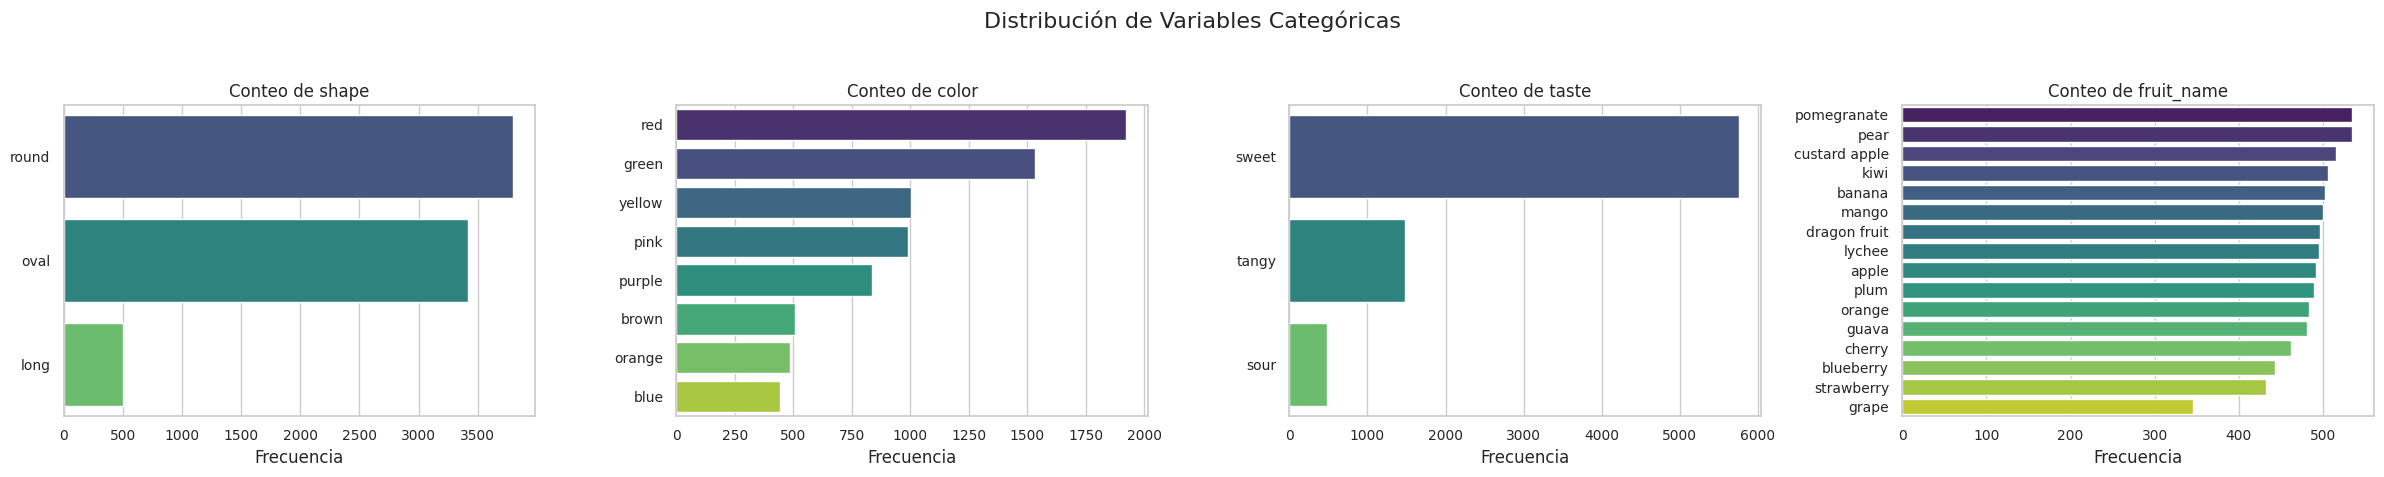

In [ ]:
# obtener columnas categoricas
categorical_columns = df.select_dtypes(include='object').columns.to_list()

print("Explorando variables categóricas:\n")

for col in categorical_columns:
    print(f"--- Columna: {col} ---")
    print(df[col].value_counts())
    print("\n")

# Visualizar distribuciones categoricas
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(6 * len(categorical_columns), 5))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16)

for i, col in enumerate(categorical_columns):
    sns.countplot(y=df[col], ax=axes[i], palette='viridis', order=df[col].value_counts().index)
    axes[i].set_title(f'Conteo de {col}')
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualización Comparativa de Outliers (Pre y Post Limpieza)

In [ ]:
#Volver a cargar el dataset para obtener comparativo pre y post limpieza
try:
    df_original = pd.read_csv(file_path, encoding="utf-8", skipinitialspace=True)
except UnicodeDecodeError:
    df_original = pd.read_csv(file_path, encoding="latin-1", skipinitialspace=True)

df_original.columns = df_original.columns.str.strip()

# Aplicar eliminacion de duplicados al df_original para obtener el data frame df_pre_outliers
df_pre_outliers = df_original.drop_duplicates().copy()

# Aplicar la eliminación de valores atípicos a df_pre_outliers para obtener df_post_outliers
df_post_outliers = df_pre_outliers.copy()
for col in numerical_columns:
    df_post_outliers = detect_and_remove_outliers_iqr(df_post_outliers, col)

print(f"\nShape of DataFrame before outlier removal (after duplicate removal): {df_pre_outliers.shape[0]} filas × {df_pre_outliers.shape[1]} columnas")
print(f"Shape of DataFrame after outlier removal: {df_post_outliers.shape[0]} filas × {df_post_outliers.shape[1]} columnas")


 Column: size (cm)
Q1: 4.00, Q3: 10.20, IQR: 6.20
Lower Bound: -5.30, Upper Bound: 19.50

 Outliers Detected (866 rows):
       size (cm)  shape  weight (g)  avg_price (₹)   color  taste  fruit_name
0          25.4  round      3089.2          137.1   green  sweet  watermelon
1          24.6  round      3283.9          163.8   green  sweet  watermelon
3          20.0   oval      1607.0           85.7  orange  sweet      papaya
43         27.2  round      2818.8          148.4   green  sweet  watermelon
50         24.8  round      3274.4          148.3   green  sweet  watermelon
...         ...    ...         ...            ...     ...    ...         ...
9938       21.0   oval      1610.0           73.3  orange  sweet      papaya
9952       26.3  round      3190.8          136.4   green  sweet  watermelon
9983       22.5  round      3202.0          156.5   green  sweet  watermelon
9988       21.5   oval      1358.7           77.7  orange  sweet      papaya
9989       19.8   oval      15

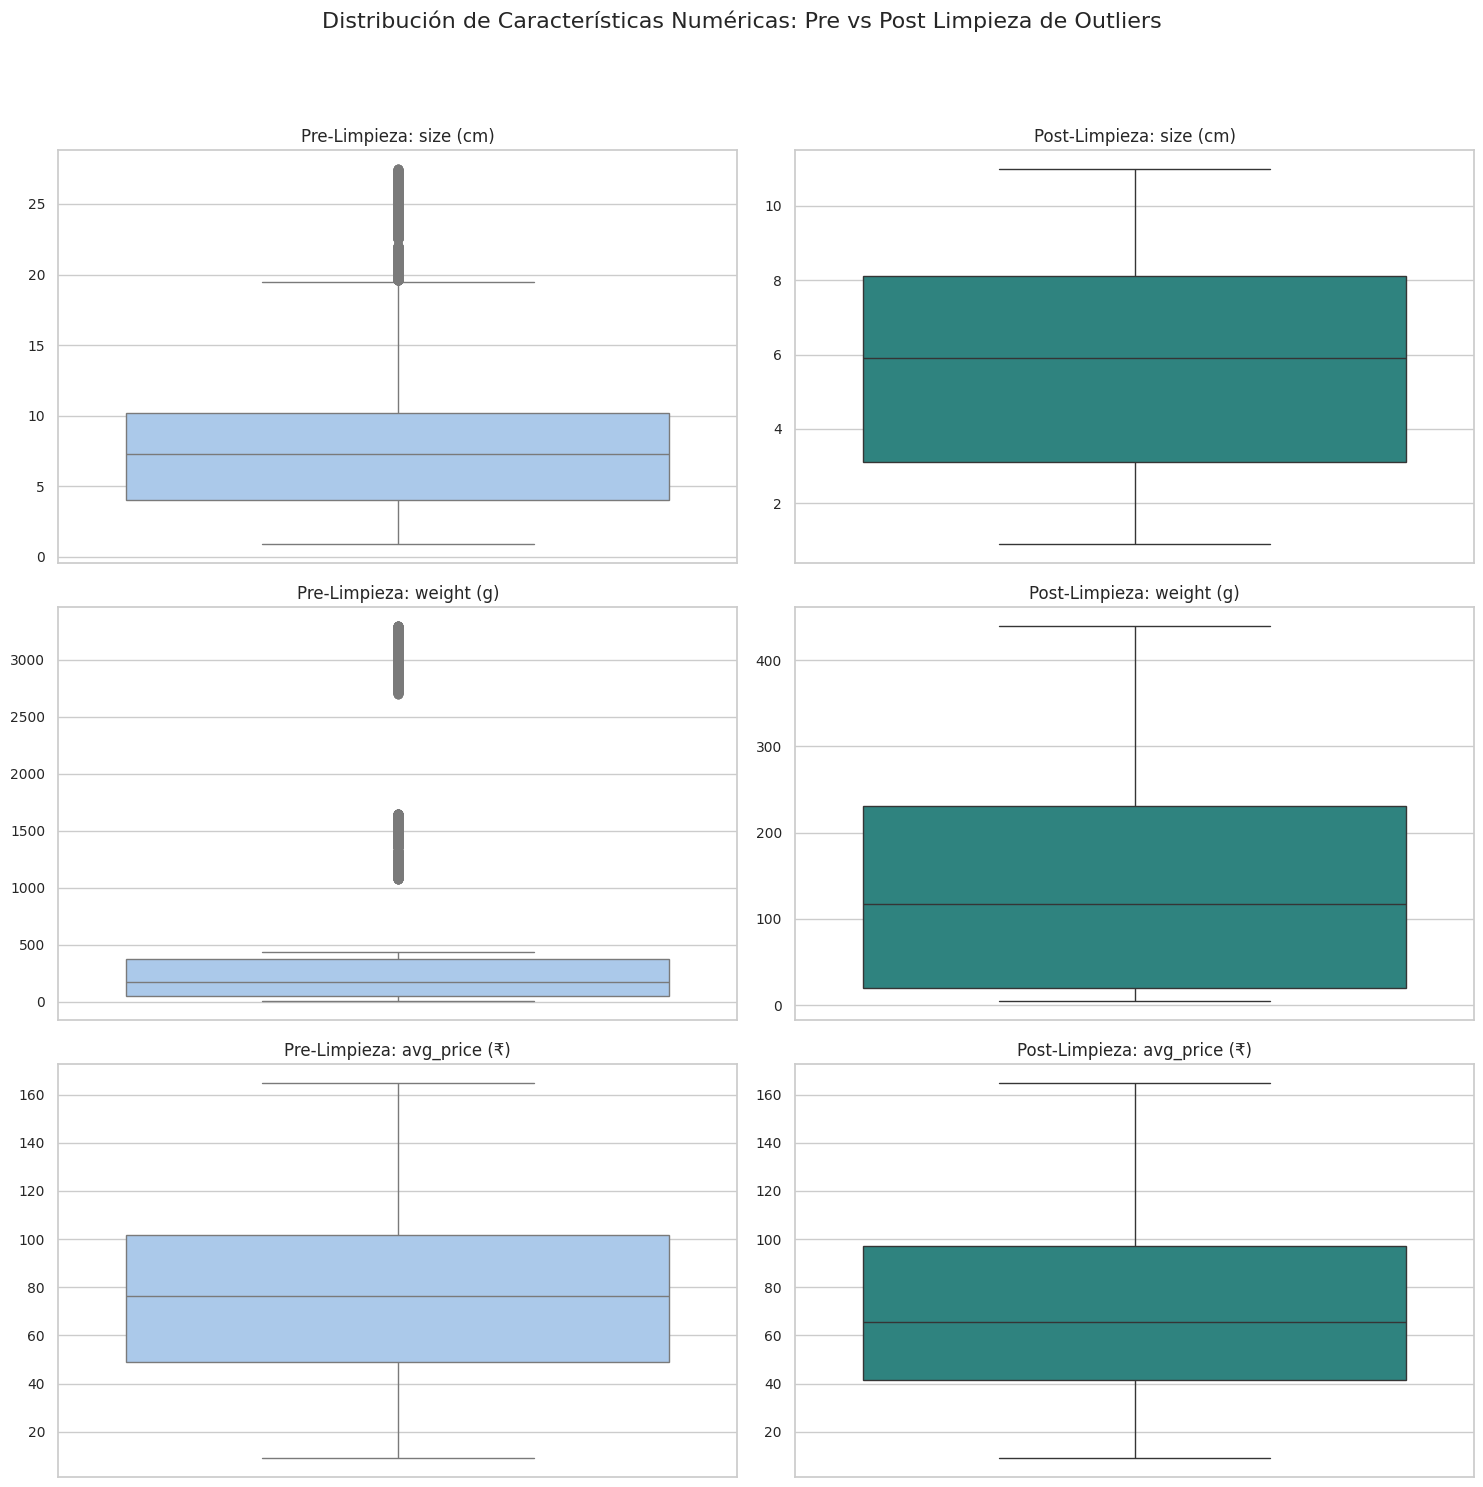

In [ ]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(15, 5 * len(numerical_columns)))
fig.suptitle('Distribución de Características Numéricas: Pre vs Post Limpieza de Outliers', fontsize=16, y=1.02)

for i, col in enumerate(numerical_columns):
    # Antes de quitar Ouliers
    sns.boxplot(y=df_pre_outliers[col], ax=axes[i, 0], palette='pastel')
    axes[i, 0].set_title(f'Pre-Limpieza: {col}')
    axes[i, 0].set_ylabel('')
    axes[i, 0].tick_params(axis='y', labelsize=10)

    # Después de quitar outliers
    sns.boxplot(y=df_post_outliers[col], ax=axes[i, 1], palette='viridis')
    axes[i, 1].set_title(f'Post-Limpieza: {col}')
    axes[i, 1].set_ylabel('')
    axes[i, 1].tick_params(axis='y', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Visualización de Datos Numéricos (Post-Limpieza de Outliers)

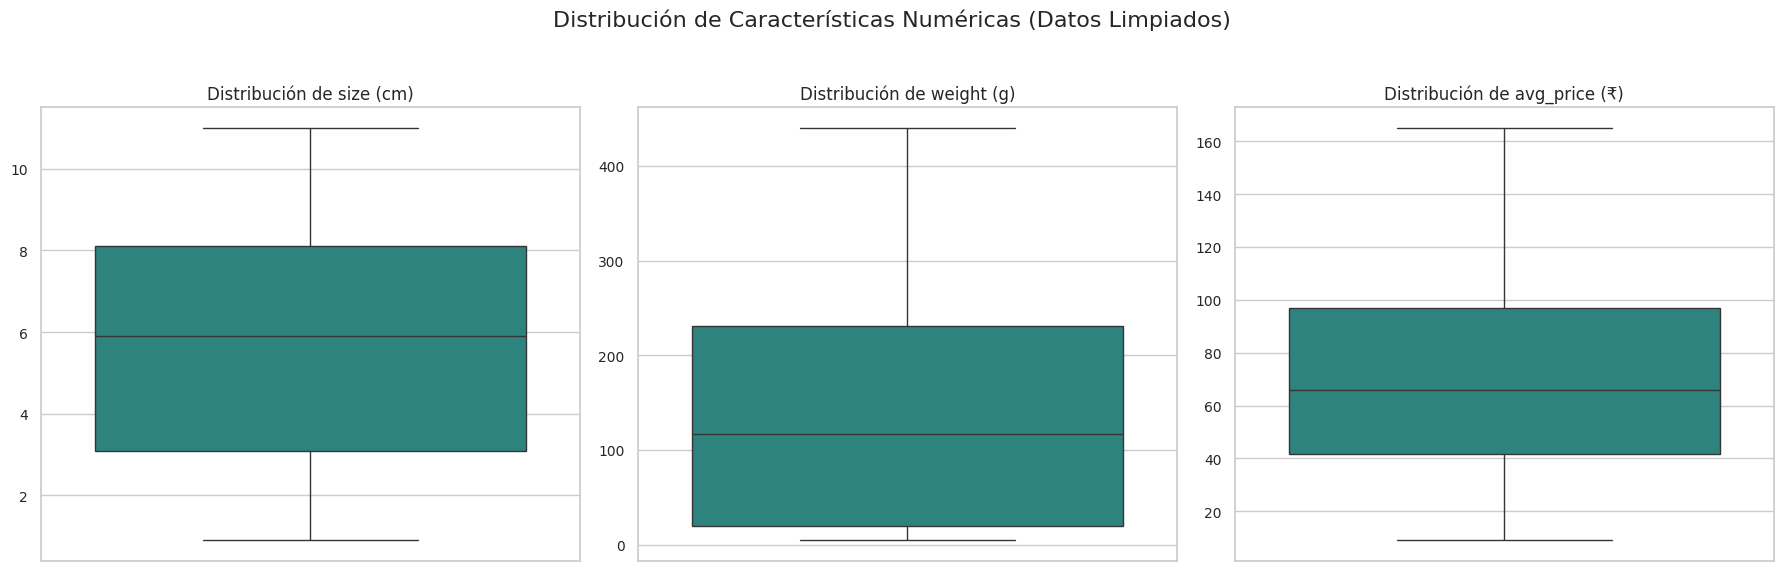

In [ ]:
fig, axes = plt.subplots(1, len(numerical_columns), figsize=(18, 6))
fig.suptitle('Distribución de Características Numéricas (Datos Limpiados)', fontsize=16)

for i, col in enumerate(numerical_columns):
    sns.boxplot(y=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
df_pre_outliers["fruit_name"].value_counts().head(10)
df_post_outliers["fruit_name"].value_counts().head(10)

,count
fruit_name,
pomegranate,534
pear,534
custard apple,516
kiwi,506
banana,502
mango,500
dragon fruit,496
lychee,495
apple,492


In [ ]:
# Conteos por clase
pre_counts  = df_pre_outliers["fruit_name"].value_counts()
post_counts = df_post_outliers["fruit_name"].value_counts()

# Tabla comparativa (alineada por índice = fruta)
comparison = pd.concat([pre_counts, post_counts], axis=1)
comparison.columns = ["pre_outliers_count", "post_outliers_count"]
comparison = comparison.fillna(0).astype(int)

# Diferencias
comparison["delta"] = comparison["post_outliers_count"] - comparison["pre_outliers_count"]
comparison["delta_pct"] = (comparison["delta"] / comparison["pre_outliers_count"]) * 100

# Ordenar por mayor pérdida relativa (más afectadas por la limpieza)
comparison_sorted = comparison.sort_values("delta_pct")

comparison_sorted.head(15)   # Top 15 más afectadas

,pre_outliers_count,post_outliers_count,delta,delta_pct
fruit_name,,,,
pineapple,533,0,-533,-100.0
papaya,509,0,-509,-100.0
coconut,502,0,-502,-100.0
watermelon,498,0,-498,-100.0
custard apple,516,516,0,0.0
pomegranate,534,534,0,0.0
kiwi,506,506,0,0.0
pear,534,534,0,0.0
banana,502,502,0,0.0


In [ ]:
pre_prop  = (pre_counts / len(df_pre_outliers)) * 100
post_prop = (post_counts / len(df_post_outliers)) * 100

prop_comp = pd.concat([pre_prop, post_prop], axis=1)
prop_comp.columns = ["pre_%", "post_%"]
prop_comp = prop_comp.fillna(0)

prop_comp["delta_%"] = prop_comp["post_%"] - prop_comp["pre_%"]

prop_comp.sort_values("delta_%").head(15)

,pre_%,post_%,delta_%
fruit_name,,,
pineapple,5.464425,0.000000,-5.464425
papaya,5.218372,0.000000,-5.218372
coconut,5.146607,0.000000,-5.146607
watermelon,5.105598,0.000000,-5.105598
grape,3.547263,4.486515,0.939252
strawberry,4.428952,5.601660,1.172708
blueberry,4.541726,5.744295,1.202568
cherry,4.736518,5.990664,1.254146
guava,4.931310,6.237033,1.305723


In [ ]:
comparison_sorted.style.format({"delta_pct": "{:.2f}%"})

,pre_outliers_count,post_outliers_count,delta,delta_pct
fruit_name,,,,
pineapple,533,0,-533,-100.00%
papaya,509,0,-509,-100.00%
coconut,502,0,-502,-100.00%
watermelon,498,0,-498,-100.00%
custard apple,516,516,0,0.00%
pomegranate,534,534,0,0.00%
kiwi,506,506,0,0.00%
pear,534,534,0,0.00%
banana,502,502,0,0.00%


In [ ]:
print("Clases pre:", df_pre_outliers["fruit_name"].nunique())
print("Clases post:", df_post_outliers["fruit_name"].nunique())

missing_classes = set(df_pre_outliers["fruit_name"].unique()) - set(df_post_outliers["fruit_name"].unique())
print("Clases perdidas:", missing_classes)

Clases pre: 20
Clases post: 16
Clases perdidas: {'papaya', 'watermelon', 'coconut', 'pineapple'}


El análisis comparativo pre y post limpieza evidenció que la aplicación del criterio IQR de manera global sobre variables numéricas generó un sesgo de selección significativo. Específicamente, las clases pineapple, papaya, coconut y watermelon presentaron una reducción del 100% de sus observaciones tras el filtrado, lo que indica que sus valores de tamaño y/o peso se ubican sistemáticamente fuera de los límites definidos por la dispersión central del conjunto. Este comportamiento sugiere que la distribución de las variables numéricas es multimodal debido a la coexistencia de subpoblaciones con escalas físicas naturalmente distintas. En consecuencia, el filtrado global de outliers no solo elimina valores extremos, sino que modifica la distribución de clases y el soporte de la distribución condicional
𝑃
(
𝑋
∣
𝑌
)
P(X∣Y), afectando la capacidad del modelo para generalizar a frutas de mayor tamaño y peso. Por lo tanto, para preservar representatividad y evitar degradación de desempeño en clases removidas, se recomienda emplear detección de outliers condicionada por clase o bien conservar dichas observaciones y tratarlas como variabilidad real del fenómeno.

**Diseño de Experimentos**

**Objetivo**

Evaluar el impacto de tratar outliers en variables numéricas sobre el desempeño de modelos de clasificación multiclase y sobre la distribución de clases, comparando tres estrategias:

E0 (Baseline): Solo eliminación de duplicados.
E1 (Outliers global IQR): Duplicados + eliminación de outliers por IQR global (tu enfoque actual).
E2 (Outliers por clase IQR): Duplicados + eliminación de outliers con IQR calculado dentro de cada fruit_name (mantiene la variabilidad “real” por fruta).

**Modelos a evaluar**

Logistic Regression (sensible a escala y a outliers → buen detector de impacto).

Random Forest (más robusto → control).

**Métricas**

Accuracy (global).

F1 macro (crítica en multiclase; penaliza clases con mal desempeño).

Matriz de confusión (para inspección, opcional).

**Validación**

Split estratificado train_test_split(..., stratify=y, random_state=42).

Mismo random_state para asegurar comparabilidad.

Checks obligatorios por experimento

Número de filas.

Número de clases.

Clases perdidas (si aplica).

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

RANDOM_STATE = 42

TARGET = "fruit_name"
NUM_COLS = ["size (cm)", "weight (g)", "avg_price (₹)"]
CAT_COLS = ["shape", "color", "taste"]

# -------------------------
# Utilidad: IQR global
# -------------------------
def remove_outliers_iqr_global(df, col, factor=1.5):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - factor * iqr
    ub = q3 + factor * iqr
    return df[(df[col] >= lb) & (df[col] <= ub)]

def apply_global_iqr(df, num_cols):
    out = df.copy()
    for col in num_cols:
        out = remove_outliers_iqr_global(out, col)
    return out

# -------------------------
# Utilidad: IQR por clase
# -------------------------
def remove_outliers_iqr_by_class(df, col, target=TARGET, factor=1.5):
    def _filter_group(g):
        q1 = g[col].quantile(0.25)
        q3 = g[col].quantile(0.75)
        iqr = q3 - q1
        lb = q1 - factor * iqr
        ub = q3 + factor * iqr
        return g[(g[col] >= lb) & (g[col] <= ub)]
    return df.groupby(target, group_keys=False).apply(_filter_group)

def apply_class_iqr(df, num_cols):
    out = df.copy()
    for col in num_cols:
        out = remove_outliers_iqr_by_class(out, col, target=TARGET)
    return out

# -------------------------
# Preprocess + Model
# -------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)
    ],
    remainder="drop"
)

models = {
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=None),
    "RF": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
}

def run_experiment(df_exp, exp_name):
    # X/y
    X = df_exp[NUM_COLS + CAT_COLS]
    y = df_exp[TARGET]

    # Split estratificado (si hay clases con muy pocos casos, puede fallar)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    results = []
    for model_name, model in models.items():
        clf = Pipeline(steps=[("prep", preprocess), ("model", model)])
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        results.append({
            "experiment": exp_name,
            "model": model_name,
            "rows": len(df_exp),
            "n_classes": y.nunique(),
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro")
        })
    return results

# -------------------------
# Construcción de datasets E0, E1, E2
# -------------------------
df_original = pd.read_csv(file_path, encoding="utf-8", skipinitialspace=True)
df_original.columns = df_original.columns.str.strip()

# E0: solo duplicados
E0 = df_original.drop_duplicates().copy()

# E1: duplicados + IQR global
E1 = apply_global_iqr(E0, NUM_COLS)

# E2: duplicados + IQR por clase
E2 = apply_class_iqr(E0, NUM_COLS)

# Reporte de clases perdidas
def class_report(df_ref, df_new, name):
    lost = set(df_ref[TARGET].unique()) - set(df_new[TARGET].unique())
    print(f"{name} -> filas: {len(df_new)}, clases: {df_new[TARGET].nunique()}, clases perdidas: {sorted(list(lost))}")

print("=== Resumen de datasets ===")
class_report(E0, E0, "E0 (baseline)")
class_report(E0, E1, "E1 (IQR global)")
class_report(E0, E2, "E2 (IQR por clase)")

# -------------------------
# Correr experimentos
# -------------------------
all_results = []
all_results += run_experiment(E0, "E0_baseline")
all_results += run_experiment(E1, "E1_iqr_global")
all_results += run_experiment(E2, "E2_iqr_by_class")

results_df = pd.DataFrame(all_results).sort_values(["experiment", "model"])
results_df

=== Resumen de datasets ===
E0 (baseline) -> filas: 9754, clases: 20, clases perdidas: []
E1 (IQR global) -> filas: 7712, clases: 16, clases perdidas: ['coconut', 'papaya', 'pineapple', 'watermelon']
E2 (IQR por clase) -> filas: 9754, clases: 20, clases perdidas: []


/tmp/ipykernel_218/1073087696.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(target, group_keys=False).apply(_filter_group)
/tmp/ipykernel_218/1073087696.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(target, group_keys=False).apply(_filter_group)
/tmp/ipykernel_218/1073087696.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. 

,experiment,model,rows,n_classes,accuracy,f1_macro
0,E0_baseline,LogReg,9754,20,1.0,1.0
1,E0_baseline,RF,9754,20,1.0,1.0
2,E1_iqr_global,LogReg,7712,16,1.0,1.0
3,E1_iqr_global,RF,7712,16,1.0,1.0
4,E2_iqr_by_class,LogReg,9754,20,1.0,1.0
5,E2_iqr_by_class,RF,9754,20,1.0,1.0


**5. Model Building**
We used a Pipeline with preprocessing and classification in one go.
Steps:
Numerical features → Standard Scaled

Categorical features → Ordinal Encoded

Model Used → RandomForestClassifier

In [ ]:
X = df.drop('fruit_name', axis=1)
y = df['fruit_name']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

X_categorical_columns = [col for col in categorical_columns if col != 'fruit_name']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ("cat", OrdinalEncoder(), X_categorical_columns) # Changed LabelEncoder to OrdinalEncoder
    ]
)

In [ ]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier())
])

In [ ]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['size (cm)', 'weight (g)',
                                                   'avg_price (₹)']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['shape', 'color',
                                                   'taste'])])),
                ('classifier', RandomForestClassifier())])

In [ ]:
y_predict  = pipeline.predict(x_test)

**6. MODEL EVALUATION**

In [ ]:
accuracy_result = accuracy_score(y_predict,y_test)

In [ ]:
cm_result = confusion_matrix(y_predict,y_test)

In [ ]:
cr_result = classification_report(y_predict,y_test)

In [ ]:
print(f"Accuracy Score : {accuracy_result}")

Accuracy Score : 1.0


In [ ]:
print(f"Confusion Matrix : \n{cm_result}")

Confusion Matrix : 
[[105   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0  93   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0  86   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0  86   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 100   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0  81   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  71   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 100   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  96   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  98   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 105   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 100   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 117   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 113   0   0]
 [  0   0   0   0   0   0   0   0   0   0 

In [ ]:
print(f"Classification Report : \n{cr_result}")

Classification Report : 
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       105
       banana       1.00      1.00      1.00        93
    blueberry       1.00      1.00      1.00        86
       cherry       1.00      1.00      1.00        86
custard apple       1.00      1.00      1.00       100
 dragon fruit       1.00      1.00      1.00        81
        grape       1.00      1.00      1.00        71
        guava       1.00      1.00      1.00       100
         kiwi       1.00      1.00      1.00        96
       lychee       1.00      1.00      1.00        98
        mango       1.00      1.00      1.00       105
       orange       1.00      1.00      1.00       100
         pear       1.00      1.00      1.00       117
         plum       1.00      1.00      1.00       113
  pomegranate       1.00      1.00      1.00       106
   strawberry       1.00      1.00      1.00        86

     accuracy                         

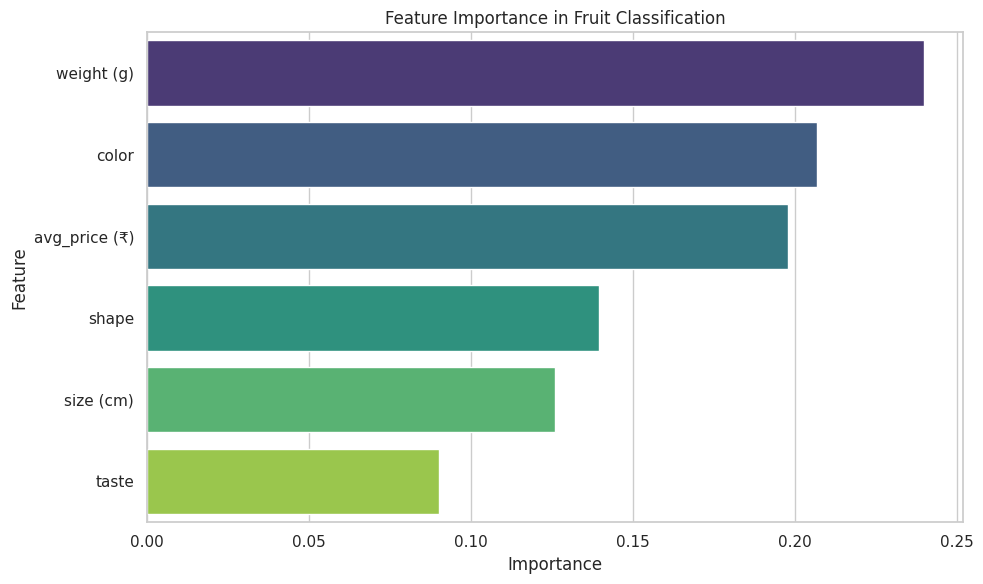

In [ ]:
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = numerical_columns + CAT_COLS # Use CAT_COLS as defined for ColumnTransformer

# Crear un DataFrame para ordenar las importancias
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Ordenar el DataFrame por importancia en orden ascendente
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6)) # Aumentar el tamaño para mejor visualización
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance in Fruit Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
#¿Qué pasa si el precio de una fruta se duplica? ¿Cambia la predicción?

sample = x_test.sample(1)
print("Original:", pipeline.predict(sample))
sample['avg_price (₹)'] *= 2
print("After Price Doubles:", pipeline.predict(sample))

Original: ['guava']
After Price Doubles: ['guava']


### Predicción del Tipo de Fruta a partir de Características Introducidas por el Usuario

En esta seccion se introducen los valores para tamaño, peso, forma, color y sabor para que el modelo prediga el tipo de fruta usando los datos de entrenamiento.

In [ ]:
import pandas as pd

print("\n--- Predicción de Fruta por Características ---")

# Simular entrada del usuario para las características de la fruta
# ¡Modifica estos valores para probar diferentes frutas!
input_size = 1.0  # en cm
input_weight = 4.9 # en gramos
input_price = 9.2 # en ₹ (aunque no sea una 'característica' directa, el modelo la necesita)
input_shape = 'round' # 'round', 'oval', 'long'
input_color = 'purple' # 'red', 'green', 'yellow', 'pink', 'purple', 'brown', 'orange', 'blue'
input_taste = 'sweet' # 'sweet', 'tangy', 'sour'

print(f"""Características introducidas:
  Tamaño: {input_size} cm
  Peso: {input_weight} g
  Precio promedio: {input_price} ₹
  Forma: {input_shape}
  Color: {input_color}
  Sabor: {input_taste}""")

# Crear un DataFrame con la entrada del usuario
user_fruit_data = pd.DataFrame({
    'size (cm)': [input_size],
    'shape': [input_shape],
    'weight (g)': [input_weight],
    'avg_price (₹)': [input_price],
    'color': [input_color],
    'taste': [input_taste]
})

# Realizar la predicción usando el pipeline entrenado
predicted_fruit = pipeline.predict(user_fruit_data)[0]

print(f"\nEl modelo predice que esta fruta es: **{predicted_fruit.upper()}**")

# Opcional: Mostrar características promedio de la fruta predicha del dataset
print(f"\nCaracterísticas promedio de la {predicted_fruit.upper()} en nuestro dataset:")
display(df[df['fruit_name'] == predicted_fruit][NUM_COLS + CAT_COLS].mean(numeric_only=True).to_frame().T)
display(df[df['fruit_name'] == predicted_fruit][CAT_COLS].mode().iloc[0].to_frame().T)



--- Predicción de Fruta por Características ---
Características introducidas:
  Tamaño: 1.0 cm
  Peso: 4.9 g
  Precio promedio: 9.2 ₹
  Forma: round
  Color: purple
  Sabor: sweet

El modelo predice que esta fruta es: **GRAPE**

Características promedio de la GRAPE en nuestro dataset:


,size (cm),weight (g),avg_price (₹)
0,0.993353,5.019075,10.018208


,shape,color,taste
0,round,purple,sweet


### Ejemplo de Sistema de Recomendación de Frutas

Este código simula una recomendación de frutas basada en las preferencias categóricas de un usuario (forma, color, sabor). El modelo utilizará estas características para predecir el tipo de fruta más probable.

In [ ]:
print("\n--- Sistema de Recomendación de Frutas ---")

# Simular entrada del usuario para las preferencias
# Puedes modificar estos valores para probar diferentes combinaciones
user_shape = 'round'
user_color = 'red'
user_taste = 'sweet'

print(f"Preferencias del usuario:\n Forma: {user_shape}, Color: {user_color}, Sabor: {user_taste}")

# Crear un DataFrame con las preferencias del usuario
# Usamos valores promedio o arbitrarios para las columnas numéricas,
# ya que el usuario no las especifica directamente en la recomendación por preferencias.
# El modelo esperará todas las columnas para predecir.

# Obtener los valores promedio de las columnas numéricas del df original o entrenado
mean_size = df['size (cm)'].mean()
mean_weight = df['weight (g)'].mean()
mean_price = df['avg_price (₹)'].mean()

user_input = pd.DataFrame({
    'size (cm)': [mean_size], # Valor por defecto, no es una preferencia directa
    'shape': [user_shape],
    'weight (g)': [mean_weight], # Valor por defecto
    'avg_price (₹)': [mean_price], # Valor por defecto
    'color': [user_color],
    'taste': [user_taste]
})

# Realizar la predicción
recommended_fruit = pipeline.predict(user_input)[0]

print(f"\nFruta recomendada: **{recommended_fruit.upper()}**")

# Opcional: Mostrar características promedio de la fruta recomendada del dataset
print(f"\nCaracterísticas promedio de la {recommended_fruit.upper()} en nuestro dataset:")
display(df[df['fruit_name'] == recommended_fruit][NUM_COLS + CAT_COLS].mean(numeric_only=True).to_frame().T)
display(df[df['fruit_name'] == recommended_fruit][CAT_COLS].mode().iloc[0].to_frame().T)



--- Sistema de Recomendación de Frutas ---
Preferencias del usuario:
 Forma: round, Color: red, Sabor: sweet

Fruta recomendada: **APPLE**

Características promedio de la APPLE en nuestro dataset:


,size (cm),weight (g),avg_price (₹)
0,5.995732,149.811992,79.753252


,shape,color,taste
0,round,red,sweet
